Comparing performance of ML approaches for activity classification.... in other words, mutli-class classification model with different algorithms comparing the performance w/ each algorithm.

-> Makes sense, 11:51 min video w/ 100 samples per sec... so hence we expect approx. 71100 samples/lines of data & note that we are not required to use VOTT or any other annotation/tagging tool
   as we are already provided with the ```a3_activity_annotations.csv``` which has already done this.

-> Classes: Walking, Standing, Jogging, Side-step (4 ttl classes)

-> ```imu data columns: timestamp, x-axis acceleration, y-axis acceleration, z-axis acceleration, x-axis gyro, y-axis gyro, z-axis gyro``` (acceleration and gyroscope values are reported in arbitrary units (16-bit signed values) which represent a range of +/- 8g for the accelerometer and +/- 8000dps (degrees-per-second) for the gyroscope.)

### Steps:
  - Align and combine a dataset captured from an inertial sensor with an activity annotation file produced from a video recording of the data capture session.
  - Visualize the combined dataset to check that the data has been correctly imported into Python and aligned with activity transitions.
  - Process the activity annotation data to assign a target activity to each data point within the IMU dataset.
  - Calculate a set of features from the raw sensor data.
  - Apply a machine learning workflow to test a selection of classification algorithms on the feature set for the task of activity classification.
  - Perform hyper-parameter optimization on at least one parameter for each algorithm.
  - Create some visualizations and report on the model that your machine learning approaches have learned from the data.


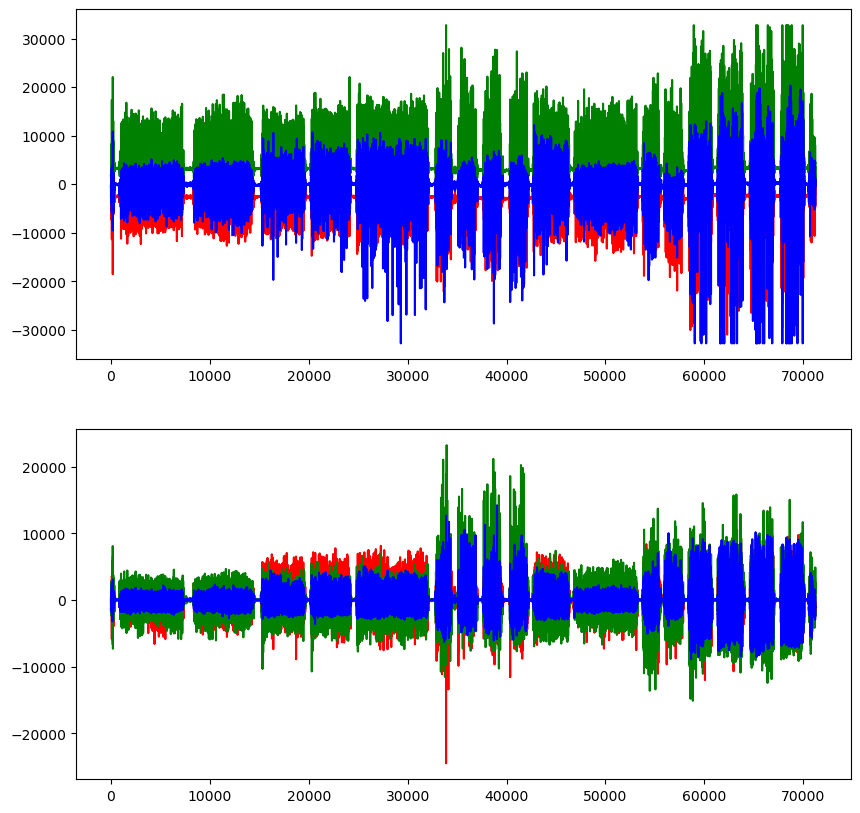

In [2]:
import csv
import matplotlib.pyplot as plt

# lists to store IMU data:

# epoch timestamps for each reading
time_track = []

# Accelerometer data:
x_axis_acceleration_data = []
y_axis_acceleration_data = []
z_axis_acceleration_data = []

# Gyrometer data:
x_axis_gyro = []
y_axis_gyro = []
z_axis_gyro = []

activity_label = []

def map_activity(activity_string):
    if activity_string == 'Standing':
        return 0
    elif activity_string == 'Walking':
        return 1
    elif activity_string == 'Side-Step':
        return 2
    elif activity_string == 'Running':
        return 3
    
with open('a3_imu_data.csv',newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        time_track.append(float(row[0]))
        x_axis_acceleration_data.append(float(row[1]))
        y_axis_acceleration_data.append(float(row[2]))
        z_axis_acceleration_data.append(float(row[3]))
        x_axis_gyro.append(float(row[4]))
        y_axis_gyro.append(float(row[5]))
        z_axis_gyro.append(float(row[6]))
        
fig,ax = plt.subplots(2,1,figsize=(10,10))
ax[0].plot(x_axis_acceleration_data, color='r')
ax[0].plot(y_axis_acceleration_data, color='g')
ax[0].plot(z_axis_acceleration_data, color='b')

ax[1].plot(x_axis_gyro, color='r')
ax[1].plot(y_axis_gyro, color='g')
ax[1].plot(z_axis_gyro, color='b')